# BBB Classification



In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC
from sklearn.metrics import confusion_matrix


## 1) Load dataset and inspect schema

In [30]:
data_path = "BBB_dataset.tsv"

df = pd.read_csv(data_path, sep="\t", low_memory=False,index_col="NO.")

print("Shape:", df.shape)
print("Columns:", len(df.columns))

non_numeric_cols = df.select_dtypes(exclude=["number"]).columns.tolist()
print("Non-numeric columns:", non_numeric_cols)
y = df["BBB+/BBB-"].map({"BBB+": 1, "BBB-": 0})

display(df.head(2))


Shape: (7807, 1624)
Columns: 1624
Non-numeric columns: ['compound_name', 'IUPAC_name', 'SMILES', 'BBB+/BBB-', 'Inchi', 'reference', 'group', 'comments']


,compound_name,IUPAC_name,SMILES,CID,logBB,BBB+/BBB-,Inchi,threshold,reference,group,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
NO.,,,,,,,,,,,,,,,,,,,,,
1,sulphasalazine,2-hydroxy-5-[[4-(pyridin-2-ylsulfamoyl)phenyl]...,O=C(O)c1cc(N=Nc2ccc(S(=O)(=O)Nc3ccccn3)cc2)ccc1O,5339.0,-2.69,BBB-,InChI=1S/C18H14N4O5S/c23-16-9-6-13(11-15(16)18...,NaN,R2|R2|R25|R46|,A,...,10.171643,63.201012,398.068491,9.477821,2428,42,144,165,9.590278,6.097222
2,moxalactam,7-[[2-carboxy-2-(4-hydroxyphenyl)acetyl]amino]...,COC1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C(=O)...,3889.0,-2.52,BBB-,InChI=1S/C20H20N6O9S/c1-25-19(22-23-24-25)36-8...,NaN,R25|,A,...,10.893010,87.033695,520.101247,9.287522,4114,62,194,237,13.756944,7.916667


**Removing target and unneccessary cols**

In [32]:
remove_cols = [
    "BBB+/BBB-","compound_name", "IUPAC_name", "SMILES","CID",
     "Inchi", "reference", "comments", "group", "logBB","threshold"
]
df = df.drop(columns=[c for c in remove_cols if c in df.columns])

In [33]:
df.head()

,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
NO.,,,,,,,,,,,,,,,,,,,,,
1,21.716720,16.307343,1,0,35.289886,2.380530,4.761059,35.289886,1.260353,4.249578,...,10.171643,63.201012,398.068491,9.477821,2428,42,144,165,9.590278,6.097222
2,27.965103,22.915028,4,0,45.430282,2.648849,5.297577,45.430282,1.261952,4.519812,...,10.893010,87.033695,520.101247,9.287522,4114,62,194,237,13.756944,7.916667
3,10.065904,8.927318,0,0,16.678194,2.425683,4.851365,16.678194,1.282938,3.505118,...,9.618402,44.825548,304.910439,16.939469,218,21,68,81,4.805556,2.861111
4,13.503979,11.612996,0,3,23.641772,2.237342,4.474683,23.641772,1.244304,3.806689,...,9.201199,50.610337,341.030979,9.743742,898,22,82,88,6.583333,4.694444
5,27.006116,19.957433,1,1,43.435426,2.709582,5.329713,43.435426,1.316225,4.477453,...,10.992336,85.350582,461.168581,7.686143,2850,74,198,254,11.229167,6.847222


# 2) EDA and preprocessing

BBB+/BBB-
1    4956
0    2851
Name: count, dtype: int64


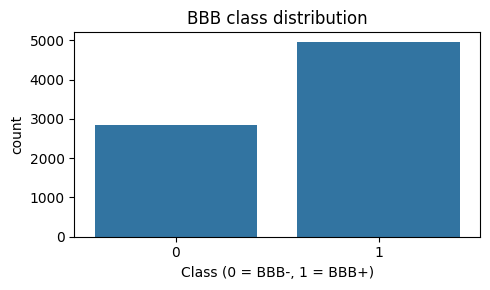

In [34]:
class_counts = y.value_counts(dropna=False)
print(class_counts)

# Plot
plt.figure(figsize=(5, 3))
sns.countplot(x=y)
plt.title("BBB class distribution")
plt.xlabel("Class (0 = BBB-, 1 = BBB+)")
plt.tight_layout()
plt.show()


**Dropping unwanted cols and target col**

**Interpretation & action:** If the classes are imbalanced (ratio far from 1), we’ll use `class_weight="balanced"` for classifiers like Logistic Regression and SVM.

## 2.1) Null values

Displaying Null values

ABC          0
ABCGG        0
nAcid        0
nBase        0
SpAbs_A     10
            ..
WPol         0
Zagreb1      0
Zagreb2      0
mZagreb1     7
mZagreb2     0
Length: 1613, dtype: int64

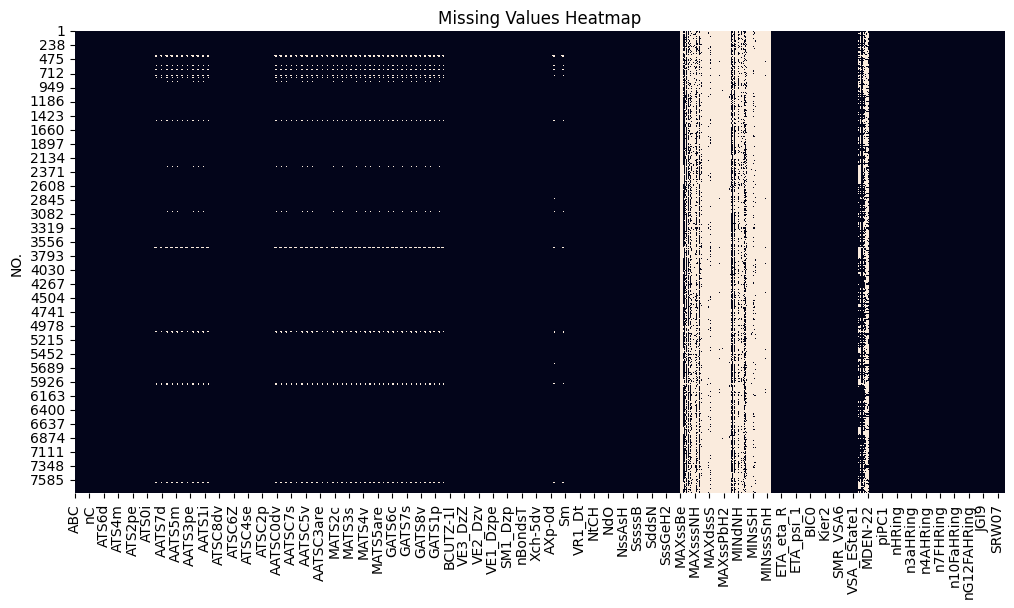

In [35]:
display(df.isnull().sum())
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

**Removing cols with more than 30% missing values**

In [36]:
threshold = 0.3 

missing_ratio = df.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > threshold].index

df = df.drop(columns=cols_to_drop)

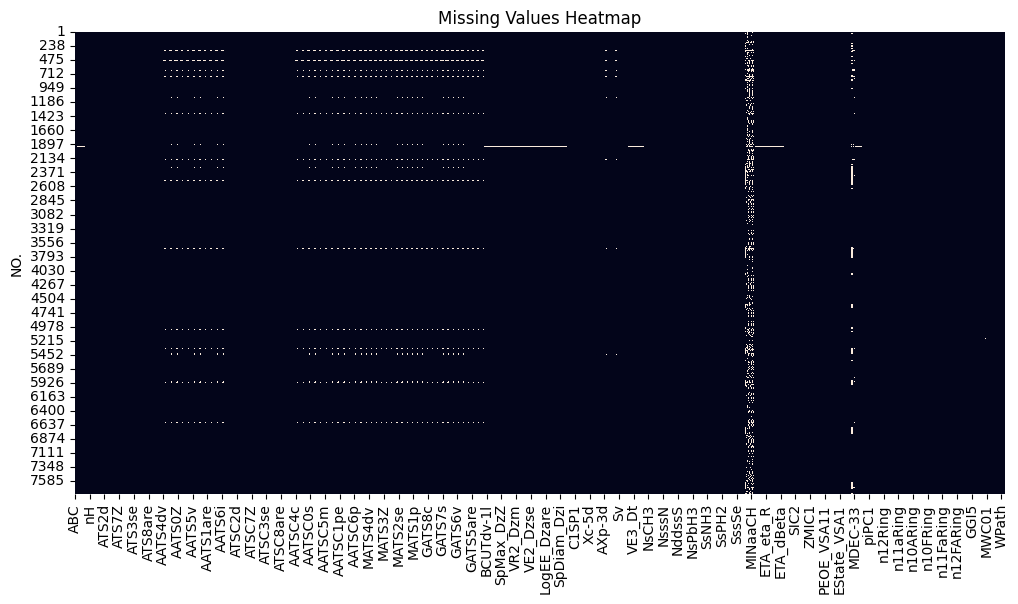

(7807, 1455)


In [37]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()
print(df.shape)

**Interpretation & action:** Many descriptors have missing values, so we’ll use median imputation and drop columns that are entirely missing.

## 2.2) Correlation Matrix

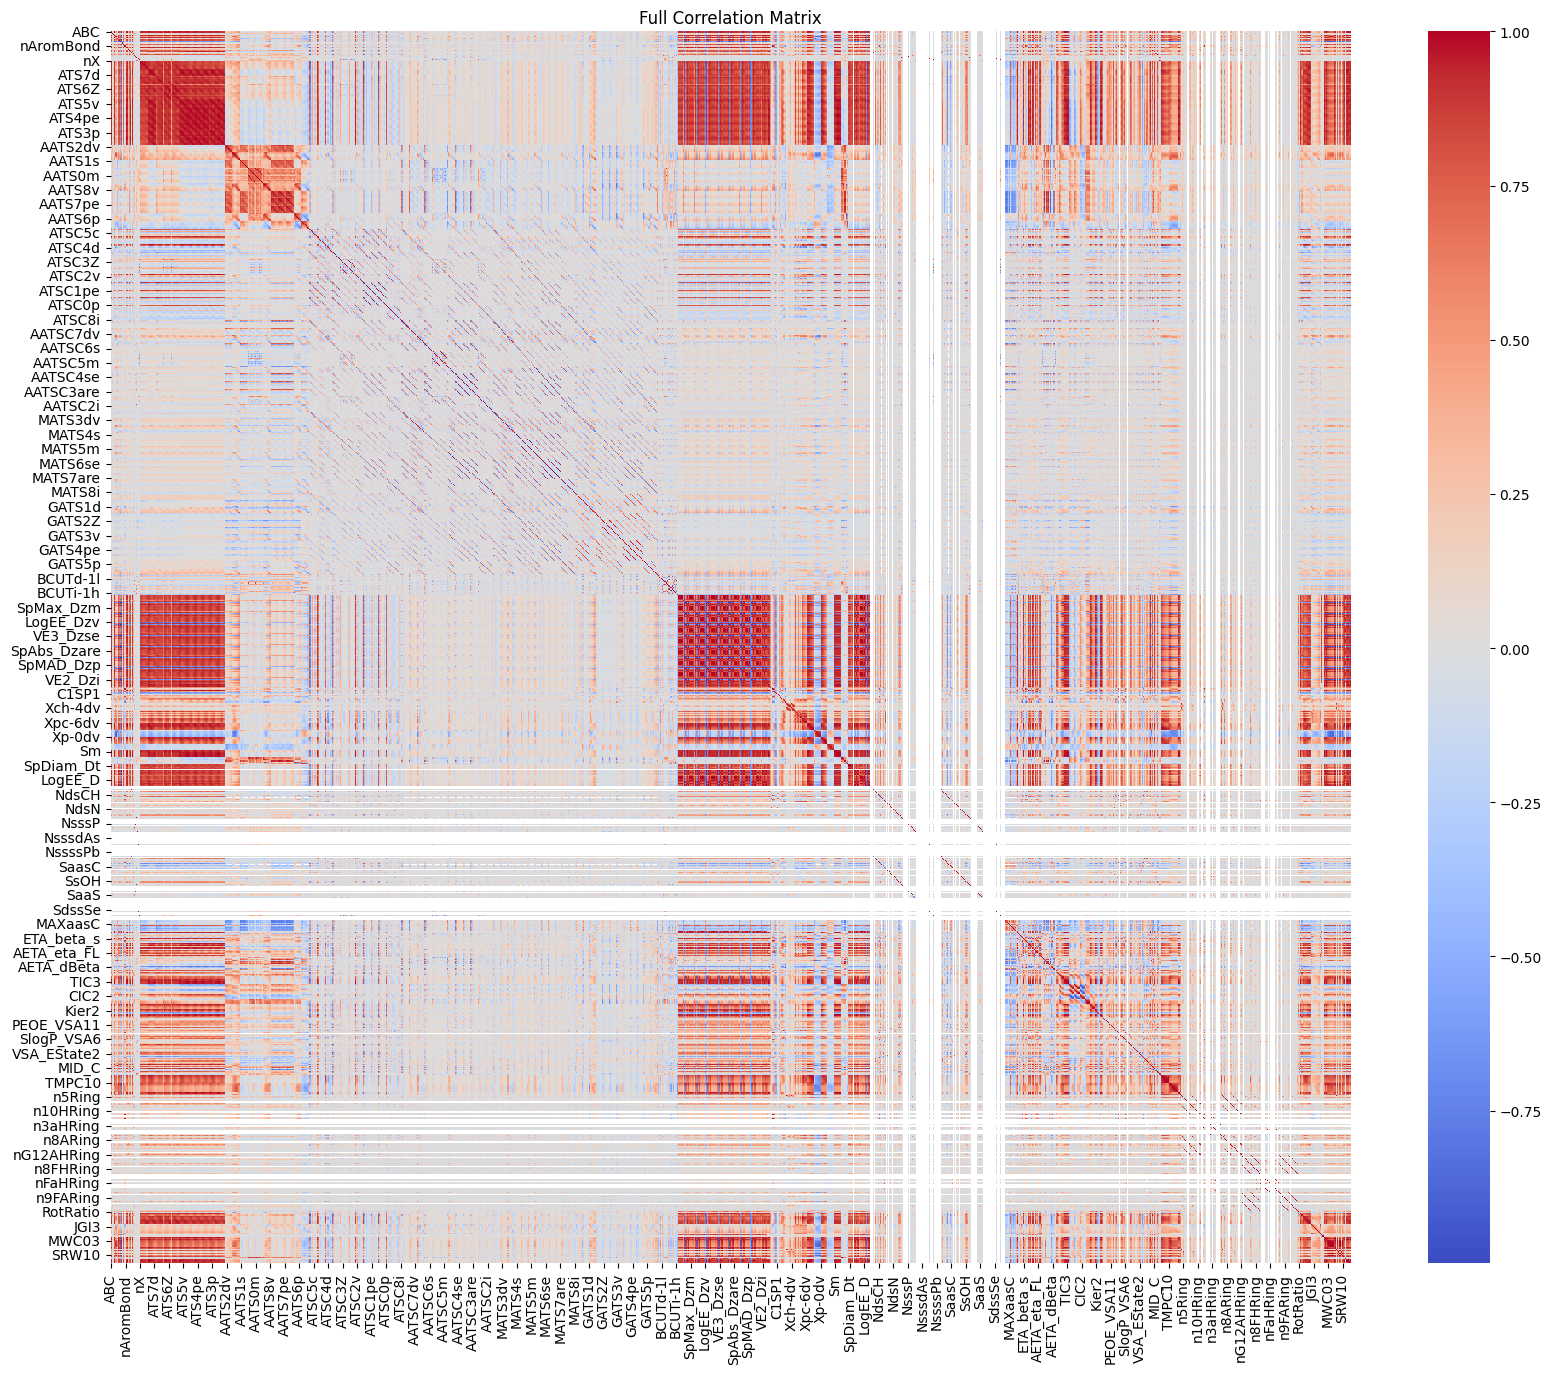

In [38]:
numeric_df = df.select_dtypes(include=["number"]).copy()
corr_matrix = numeric_df.corr()

plt.figure(figsize=(20, 16))  # increase size a lot
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Full Correlation Matrix")
plt.show()

**Removing one col from highly correlated pair**

In [39]:
corr_matrix = numeric_df.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

df = numeric_df.drop(columns=to_drop)

In [40]:
print(df)

            ABC  nAcid  nBase   SpMax_A   SpMAD_A     VE1_A        VR1_A  \
NO.                                                                        
1     21.716720      1      0  2.380530  1.260353  4.471033   242.181498   
2     27.965103      4      0  2.648849  1.261952  4.024851  1155.736978   
3     10.065904      0      0  2.425683  1.282938  3.363390    53.222139   
4     13.503979      0      3  2.237342  1.244304  3.290631   329.077251   
5     27.006116      1      1  2.709582  1.316225  4.332407  1028.101058   
...         ...    ...    ...       ...       ...       ...          ...   
7803  15.515909      0      2  2.326623  1.346938  4.106193   119.951796   
7804  16.918192      0      1  2.483200  1.312977  3.811754   252.798941   
7805  17.653808      0      1  2.511472  1.332089  4.182891   154.764251   
7806  12.118275      0      0  2.390361  1.274302  3.625609    81.331788   
7807  10.744501      0      0  2.335372  1.310634  3.500479    62.286052   

         VR

**Correlation B/W columns after reduction**

In [ ]:
numeric_df = df.select_dtypes(include=["number"]).copy()
corr_matrix = numeric_df.corr()

plt.figure(figsize=(20, 16))  # increase size a lot
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Full Correlation Matrix")
plt.show()

In [42]:
print(df.shape)

(7807, 679)


**Interpretation:**

**Still too many features to analyse**

**Trying L1 regularized logistic regression method**

### Logistic Regression with L1 (feature selection)

L1 regularization shrinks many coefficients to exactly zero, so non-zero coefficients are the selected features to keep note of.

In [43]:
X = df.copy()

In [44]:
# L1 Logistic Regression = simple feature selection
# (Keeps only important features)

# Handle missing values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True)).fillna(0)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# L1 Logistic Regression
l1_model = LogisticRegression(
    penalty="l1", solver="liblinear", C=0.1,
    max_iter=5000, class_weight="balanced"
)
l1_model.fit(X_train_scaled, y_train)

# Evaluate
pred = l1_model.predict(X_test_scaled)
prob = l1_model.predict_proba(X_test_scaled)[:, 1]

print("=== L1 Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, pred))
print("F1 Score:", f1_score(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, prob))

# Selected features (non-zero coefficients)
coef = pd.Series(l1_model.coef_[0], index=X.columns)
selected_features = coef[coef != 0]

print("\nTotal features:", X.shape[1])
print("Selected features:", len(selected_features))
print("\nTop 20 selected features:")
print(selected_features.abs().sort_values(ascending=False).head(20))

=== L1 Logistic Regression ===
Accuracy: 0.854673495518566
F1 Score: 0.885179564997471
ROC AUC: 0.9268083262591965

Total features: 679
Selected features: 218

Top 20 selected features:
MDEC-33        0.516774
ATSC6se        0.460539
VSA_EState7    0.367845
GATS2p         0.364776
CIC0           0.351544
NssssN         0.349633
nG12Ring       0.347215
SaasC          0.346938
C3SP2          0.342722
PEOE_VSA6      0.337117
AATS3p         0.334595
Xch-5d         0.333686
nAcid          0.330145
Lipinski       0.300246
PEOE_VSA9      0.286420
GATS3p         0.283472
JGI2           0.279330
EState_VSA5    0.278116
AATSC1i        0.267779
NsOH           0.266751
dtype: float64


### SVM Linear on top 50 L1-selected features

Use the top 50 features ranked by L1 absolute coefficient, then train and evaluate an Linear SVM on that reduced feature set.

In [45]:
# Select top 50
top50_features = selected_features.abs().sort_values(ascending=False).head(50).index.tolist()

X_train_top50 = X_train[top50_features]
X_test_top50 = X_test[top50_features]

# SCALE AGAIN 
scaler_top50 = StandardScaler()
X_train_top50_scaled = scaler_top50.fit_transform(X_train_top50)
X_test_top50_scaled = scaler_top50.transform(X_test_top50)

# Train Linear SVM
svm_top50 = SVC(
    kernel="linear",
    C=1.0,
    class_weight="balanced",
    probability=True
)

svm_top50.fit(X_train_top50_scaled, y_train)

# Evaluate
pred = svm_top50.predict(X_test_top50_scaled)
prob = svm_top50.predict_proba(X_test_top50_scaled)[:, 1]
print("=== Linear SVM (Top 50 Features, Scaled) ===")
print("Accuracy:", accuracy_score(y_test, pred))
print("F1 Score:", f1_score(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, prob))

=== Linear SVM (Top 50 Features, Scaled) ===
Accuracy: 0.8437900128040973
F1 Score: 0.877139979859013
ROC AUC: 0.9055620401810979


**SVM linear trained on Top 20 features**

In [46]:
# Select top 20
top20_features = selected_features.abs().sort_values(ascending=False).head(20).index.tolist()

X_train_top20 = X_train[top20_features]
X_test_top20 = X_test[top20_features]

# SCALE
scaler_top20 = StandardScaler()
X_train_top20_scaled = scaler_top20.fit_transform(X_train_top20)
X_test_top20_scaled = scaler_top20.transform(X_test_top20)

# Train Linear SVM
svm_top20 = SVC(
    kernel="linear",
    C=1.0,
    class_weight="balanced",
    probability=True
)

svm_top20.fit(X_train_top20_scaled, y_train)

# Evaluate
pred = svm_top20.predict(X_test_top20_scaled)
prob = svm_top20.predict_proba(X_test_top20_scaled)[:, 1]

print("=== Linear SVM (Top 20 Features, Scaled) ===")
print("Accuracy:", accuracy_score(y_test, pred))
print("F1 Score:", f1_score(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, prob))


=== Linear SVM (Top 20 Features, Scaled) ===
Accuracy: 0.8169014084507042
F1 Score: 0.8584158415841584
ROC AUC: 0.8699419920769667


**Compress top 20 into 8 based on PCA**

### PCA compression: top 20 features → 8 components

Take the top 20 L1-ranked features, reduce them to 8 principal components, and train a linear SVM on the compressed representation.

Using precomputed L1-selected features...
Top 20 features: ['MDEC-33', 'ATSC6se', 'VSA_EState7', 'GATS2p', 'CIC0', 'NssssN', 'nG12Ring', 'SaasC', 'C3SP2', 'PEOE_VSA6', 'AATS3p', 'Xch-5d', 'nAcid', 'Lipinski', 'PEOE_VSA9', 'GATS3p', 'JGI2', 'EState_VSA5', 'AATSC1i', 'NsOH']

Explained variance ratio: [0.18385197 0.12928514 0.09304625 0.07866775 0.06899636 0.06216139
 0.05013244 0.04644111]
Total variance explained: 0.7125824105958725

=== Linear SVM (PCA 20 → 8) ===
Accuracy: 0.8220230473751601
F1 Score: 0.8660886319845857
ROC AUC: 0.8539049235993208


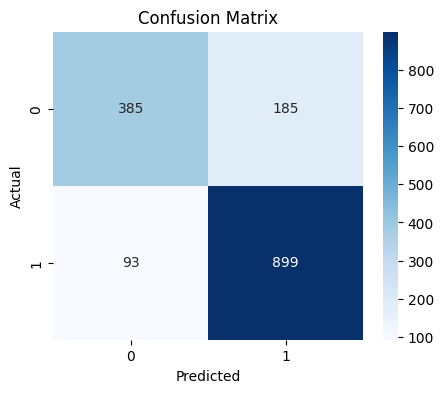

In [48]:
# PCA compression: top 20 features → 8 components
# Then train a simple linear SVM

# Use precomputed L1-selected features
print("Using precomputed L1-selected features...")

top_features = (
    selected_features.abs()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

print("Top 20 features:", top_features)

X_train_sel = X_train[top_features]
X_test_sel = X_test[top_features]

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

# PCA (20 → 8)
pca = PCA(n_components=8)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nExplained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", np.sum(pca.explained_variance_ratio_))

# Linear SVM
model = SVC(kernel="linear",  class_weight="balanced", probability=True)
model.fit(X_train_pca, y_train)

# Evaluate
y_pred = model.predict(X_test_pca)
y_prob = model.predict_proba(X_test_pca)[:, 1]

print("\n=== Linear SVM (PCA 20 → 8) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()



Using precomputed L1-selected features...
Top 20 features: ['MDEC-33', 'ATSC6se', 'VSA_EState7', 'GATS2p', 'CIC0', 'NssssN', 'nG12Ring', 'SaasC', 'C3SP2', 'PEOE_VSA6', 'AATS3p', 'Xch-5d', 'nAcid', 'Lipinski', 'PEOE_VSA9', 'GATS3p', 'JGI2', 'EState_VSA5', 'AATSC1i', 'NsOH']

Explained variance ratio: [0.18385197 0.12928514 0.09304625 0.07866775]
Total variance explained: 0.48485111066103287

=== Linear SVM (PCA 20 → 4) ===
Accuracy: 0.7996158770806658
F1 Score: 0.8501675442795597
ROC AUC: 0.8225859507640069

Number of support vectors: 3630
Sample predictions: [0 1 0 1 0 0 1 1 1 1]


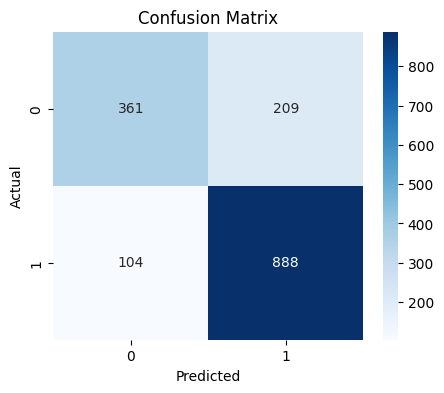

In [49]:
# PCA compression: top 20 features → 4 components
# Then train a simple linear SVM

# Use precomputed L1-selected features
print("Using precomputed L1-selected features...")

top_features = (
    selected_features.abs()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

print("Top 20 features:", top_features)

X_train_sel = X_train[top_features]
X_test_sel = X_test[top_features]

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

# PCA (20 → 4)
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nExplained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", np.sum(pca.explained_variance_ratio_))

# Linear SVM
model = SVC(kernel="linear", class_weight="balanced", probability=True)
model.fit(X_train_pca, y_train)

# Evaluate
y_pred = model.predict(X_test_pca)
y_prob = model.predict_proba(X_test_pca)[:, 1]

print("\n=== Linear SVM (PCA 20 → 4) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nNumber of support vectors:", len(model.support_))
print("Sample predictions:", y_pred[:10])

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**2-3% accuracy diff bw 8 components and 4 components**

**Now trying QML**

**QML with PCA with 4 features and 4 qubits**

Using precomputed L1-selected features...
Top 20 features: ['MDEC-33', 'ATSC6se', 'VSA_EState7', 'GATS2p', 'CIC0', 'NssssN', 'nG12Ring', 'SaasC', 'C3SP2', 'PEOE_VSA6', 'AATS3p', 'Xch-5d', 'nAcid', 'Lipinski', 'PEOE_VSA9', 'GATS3p', 'JGI2', 'EState_VSA5', 'AATSC1i', 'NsOH']

Explained variance ratio: [0.18385197 0.12928514 0.09304625 0.07866775]
Total variance explained: 0.48485111066103287

Check bounds AFTER [0, π] scaling:
Train min: 0.0 max: 3.1415926534405867
Test  min: 0.0 max: 3.141592653589793
Train size: 100 | Test size: 30


/var/folders/46/gk2t4snj69j52pxnsnxns7z80000gn/T/ipykernel_4929/454662517.py:84: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(



=== Quantum SVM (PCA 20 → 4) ===
Accuracy: 0.7333333333333333
F1 Score: 0.8181818181818182
ROC AUC: 0.7511961722488039


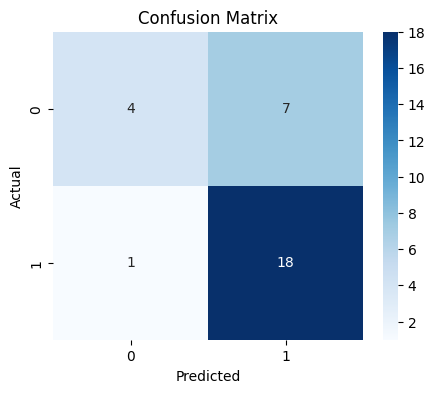

In [50]:
# ==============================
# 1. Use precomputed L1 features
# ==============================
print("Using precomputed L1-selected features...")

top_features = (
    selected_features.abs()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

print("Top 20 features:", top_features)

X_train_sel = X_train[top_features]
X_test_sel = X_test[top_features]

# ==============================
# 2. Scale
# ==============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

# ==============================
# 3. PCA (20 → 4)
# ==============================
pca = PCA(n_components=4)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nExplained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", np.sum(pca.explained_variance_ratio_))

# ==============================
# 4. Normalize for Quantum [0, π]  
# ==============================
def fit_minmax(X):
    return X.min(axis=0), X.max(axis=0)

def apply_minmax(X, X_min, X_max):
    X_scaled = (X - X_min) / (X_max - X_min + 1e-9)
    X_scaled = X_scaled * np.pi
    X_scaled = np.clip(X_scaled, 0, np.pi)
    
    return X_scaled


# Fit ONLY on training data
X_min, X_max = fit_minmax(X_train_pca)

# Apply to both
X_train_pca = apply_minmax(X_train_pca, X_min, X_max)
X_test_pca  = apply_minmax(X_test_pca, X_min, X_max)

print("\nCheck bounds AFTER [0, π] scaling:")
print("Train min:", X_train_pca.min(), "max:", X_train_pca.max())
print("Test  min:", X_test_pca.min(), "max:", X_test_pca.max())

# ==============================
# 5. Reduce dataset size
# ==============================
X_train_q, _, y_train_q, _ = train_test_split(
    X_train_pca, y_train,
    train_size=100,
    random_state=42,
    stratify=y_train
)

X_test_q, _, y_test_q, _ = train_test_split(
    X_test_pca, y_test,
    train_size=30,
    random_state=42,
    stratify=y_test
)

print("Train size:", len(X_train_q), "| Test size:", len(X_test_q))

# ==============================
# 6. Quantum Kernel + QSVC
# ==============================
feature_map = ZZFeatureMap(
    feature_dimension=4,
    reps=2,
    entanglement="linear"
)

quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

qsvc_model = QSVC(quantum_kernel=quantum_kernel)
qsvc_model.fit(X_train_q, y_train_q)

# ==============================
# 7. Evaluation
# ==============================
y_pred = qsvc_model.predict(X_test_q)

print("\n=== Quantum SVM (PCA 20 → 4) ===")
print("Accuracy:", accuracy_score(y_test_q, y_pred))
print("F1 Score:", f1_score(y_test_q, y_pred))

try:
    y_score = qsvc_model.decision_function(X_test_q)
    print("ROC AUC:", roc_auc_score(y_test_q, y_score))
except Exception:
    print("ROC AUC not available")

cm = confusion_matrix(y_test_q, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Saving our Circuit (for 4 qubit)**

In [51]:
from qiskit.circuit.library import ZZFeatureMap
from qiskit import qasm2
import numpy as np

# ==============================
# 1. MATCH QSVC PIPELINE
# ==============================
feature_dimension = 4

feature_map = ZZFeatureMap(
    feature_dimension=feature_dimension,
    reps=2,
    entanglement="linear"
)

# ==============================
# 2. Get REAL sample
# ==============================
top_features = (
    selected_features.abs()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

X_real = X_train[top_features]

# SAME preprocessing
X_real_scaled = scaler.transform(X_real)
X_real_pca = pca.transform(X_real_scaled)

# ==============================
# 3. SAFE QUANTUM SCALING
# ==============================
def apply_minmax_safe(X, X_min, X_max):
    X_scaled = (X - X_min) / (X_max - X_min + 1e-9)
    X_scaled = X_scaled * np.pi
    
    # HARD CLIP (guaranteed bounds)
    X_scaled = np.clip(X_scaled, 0.0, np.pi)
    
    return X_scaled

X_real_pca = apply_minmax_safe(X_real_pca, X_min, X_max)

real_sample = X_real_pca[0]



# ==============================
# 4. Build circuit
# ==============================
circuit = feature_map.decompose().copy()

if circuit.num_clbits == 0:
    circuit.measure_all()

# ==============================
# 5. Bind parameters
# ==============================
params = sorted(circuit.parameters, key=lambda x: x.name)

if len(params) != len(real_sample):
    raise ValueError(
        f"Mismatch: {len(params)} params vs {len(real_sample)} features"
    )

bind_values = {
    param: float(real_sample[i])
    for i, param in enumerate(params)
}

circuit = circuit.assign_parameters(bind_values)


# ==============================
# 6. Export QASM
# ==============================
qasm_text = qasm2.dumps(circuit)

qasm_path = "qsvc_feature_map_4_qubits.qasm"
with open(qasm_path, "w") as f:
    f.write(qasm_text)

print(f"\nQASM saved to: {qasm_path}")
print("\nQASM preview (first 15 lines):")
print("\n".join(qasm_text.splitlines()[:15]))


QASM saved to: qsvc_feature_map_4_qubits.qasm

QASM preview (first 15 lines):
OPENQASM 2.0;
include "qelib1.inc";
qreg q[4];
creg meas[4];
h q[0];
p(1.8540152252443662) q[0];
h q[1];
p(2.9522301936199735) q[1];
cx q[0],q[1];
p(7.376683366623686) q[1];
cx q[0],q[1];
h q[0];
p(1.8540152252443662) q[0];
h q[2];
p(3.5121833061739935) q[2];


/var/folders/46/gk2t4snj69j52pxnsnxns7z80000gn/T/ipykernel_4929/1537204608.py:10: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


**Same training and testing data size in classical ML for comparision**

In [52]:
# PCA compression: top 20 features → 4 components
# Then train a simple linear SVM

print("Using precomputed L1-selected features...")

top_features = (
    selected_features.abs()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

print("Top 20 features:", top_features)

X_train_sel = X_train[top_features]
X_test_sel = X_test[top_features]

# ==============================
# Scale
# ==============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

# ==============================
# PCA (20 → 4)
# ==============================
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nExplained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", np.sum(pca.explained_variance_ratio_))

# ==============================
# Reduce dataset 
# ==============================
X_train_small, _, y_train_small, _ = train_test_split(
    X_train_pca, y_train,
    train_size=60,
    random_state=42,
    stratify=y_train
)

X_test_small, _, y_test_small, _ = train_test_split(
    X_test_pca, y_test,
    train_size=30,
    random_state=42,
    stratify=y_test
)

print("Train size:", len(X_train_small), "| Test size:", len(X_test_small))

# ==============================
# Linear SVM
# ==============================
model = SVC(kernel="linear", C=1, class_weight="balanced", probability=True)
model.fit(X_train_small, y_train_small)

# ==============================
# Evaluate
# ==============================
y_pred = model.predict(X_test_small)
y_prob = model.predict_proba(X_test_small)[:, 1]

print("\n=== Linear SVM (PCA 20 → 4, 200/80 split) ===")
print("Accuracy:", accuracy_score(y_test_small, y_pred))
print("F1 Score:", f1_score(y_test_small, y_pred))
print("ROC AUC:", roc_auc_score(y_test_small, y_prob))



Using precomputed L1-selected features...
Top 20 features: ['MDEC-33', 'ATSC6se', 'VSA_EState7', 'GATS2p', 'CIC0', 'NssssN', 'nG12Ring', 'SaasC', 'C3SP2', 'PEOE_VSA6', 'AATS3p', 'Xch-5d', 'nAcid', 'Lipinski', 'PEOE_VSA9', 'GATS3p', 'JGI2', 'EState_VSA5', 'AATSC1i', 'NsOH']

Explained variance ratio: [0.18385197 0.12928514 0.09304625 0.07866775]
Total variance explained: 0.48485111066103287
Train size: 60 | Test size: 30

=== Linear SVM (PCA 20 → 4, 200/80 split) ===
Accuracy: 0.7666666666666667
F1 Score: 0.8372093023255814
ROC AUC: 0.8181818181818181


**ON IBM Hardware**

**API Key part**

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="your_token",
    overwrite=True
)

**QSVC on a actual Quantum Computer**

In [53]:
# ==============================
# 0. Imports
# ==============================
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import ZZFeatureMap
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==============================
# 1. DATA PREPARATION
# ==============================
# Assume X, y already loaded

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA → 4 features (matches qubits)
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# ==============================
# Quantum normalization [0, π]
# ==============================
def fit_minmax(X):
    return X.min(axis=0), X.max(axis=0)

def apply_minmax(X, X_min, X_max):
    X_scaled = (X - X_min) / (X_max - X_min + 1e-9)
    X_scaled = X_scaled * np.pi
    return np.clip(X_scaled, 0, np.pi)

X_min, X_max = fit_minmax(X_train_pca)

X_train_q = apply_minmax(X_train_pca, X_min, X_max)
X_test_q  = apply_minmax(X_test_pca, X_min, X_max)

y_train_q = y_train.values if hasattr(y_train, "values") else y_train
y_test_q  = y_test.values if hasattr(y_test, "values") else y_test

# ==============================
# 2. CONNECT TO IBM BACKEND
# ==============================
service = QiskitRuntimeService()

backend = service.least_busy(
    simulator=False,
    operational=True,
    min_num_qubits=4
)

print("Using backend:", backend)

sampler = Sampler(mode=backend)

# ==============================
# 3. FEATURE MAP
# ==============================
feature_map = ZZFeatureMap(
    feature_dimension=4,
    reps=2,
    entanglement="linear"
)

# ==============================
# 4. BUILD KERNEL CIRCUIT
# ==============================
def build_kernel_circuit(x, x_prime):
    n = len(x)
    qc = QuantumCircuit(n, n)

    qc.compose(feature_map.assign_parameters(x), inplace=True)
    qc.compose(feature_map.assign_parameters(x_prime).inverse(), inplace=True)

    qc.measure(range(n), range(n))  # REQUIRED for Sampler V2

    return qc

# ==============================
# 5. OFFICIAL COUNTS EXTRACTION
# ==============================
def extract_prob_0000(result, n_qubits):
    pub_result = result[0]

    # Official method (works across backends)
    if hasattr(pub_result, "join_data"):
        counts = pub_result.join_data().get_counts()
    else:
        # fallback (rare cases)
        data = pub_result.data
        counts = None
        for attr in dir(data):
            obj = getattr(data, attr)
            if hasattr(obj, "get_counts"):
                counts = obj.get_counts()
                break

    if counts is None:
        raise ValueError("Counts extraction failed")

    total = sum(counts.values())
    zero_state = "0" * n_qubits

    return counts.get(zero_state, 0) / total

# ==============================
# 6. BUILD KERNEL MATRIX
# ==============================
def build_kernel_matrix(X1, X2, shots=1024):
    K = np.zeros((len(X1), len(X2)))

    for i in range(len(X1)):
        for j in range(len(X2)):
            print(f"Running pair ({i}, {j})")

            qc = build_kernel_circuit(X1[i], X2[j])
            qc_t = transpile(qc, backend)

            job = sampler.run([qc_t], shots=shots)
            result = job.result()

            prob_0000 = extract_prob_0000(result, qc.num_qubits)

            K[i, j] = prob_0000

            print(f"K[{i},{j}] = {K[i,j]:.4f}")

    return K

# ==============================
# 7. REDUCE DATASET (SAFE SIZE)
# ==============================
X_train_small = X_train_q[:4]
y_train_small = y_train_q[:4]

X_test_small = X_test_q[:2]
y_test_small = y_test_q[:2]

print("Train labels:", y_train_small)
print("Unique labels:", np.unique(y_train_small))

# ==============================
# 8. COMPUTE KERNEL MATRICES
# ==============================
print("\nBuilding TRAIN kernel...")
K_train = build_kernel_matrix(X_train_small, X_train_small)

print("\nBuilding TEST kernel...")
K_test = build_kernel_matrix(X_test_small, X_train_small)

print("\nK_train:\n", K_train)

# ==============================
# 9. TRAIN SVM
# ==============================
model = SVC(kernel="precomputed")
model.fit(K_train, y_train_small)

# ==============================
# 10. EVALUATE
# ==============================
y_pred = model.predict(K_test)

print("\n=== QSVC (IBM Hardware) ===")
print("Accuracy:", accuracy_score(y_test_small, y_pred))
print("F1 Score:", f1_score(y_test_small, y_pred))

qiskit_runtime_service.__init__:WARNING:2026-04-03 09:21:06,944: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-03 09:21:08,170: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-03 09:21:12,471: Using instance: open-instance, plan: open
/var/folders/46/gk2t4snj69j52pxnsnxns7z80000gn/T/ipykernel_4929/1262851812.py:70: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note

Using backend: <IBMBackend('ibm_fez')>
Train labels: [1 1 0 0]
Unique labels: [0 1]

Building TRAIN kernel...
Running pair (0, 0)
K[0,0] = 0.8633
Running pair (0, 1)
K[0,1] = 0.0049
Running pair (0, 2)
K[0,2] = 0.1426
Running pair (0, 3)
K[0,3] = 0.0127
Running pair (1, 0)
K[1,0] = 0.0137
Running pair (1, 1)
K[1,1] = 0.8643
Running pair (1, 2)
K[1,2] = 0.0498
Running pair (1, 3)
K[1,3] = 0.0645
Running pair (2, 0)
K[2,0] = 0.1299
Running pair (2, 1)
K[2,1] = 0.0459
Running pair (2, 2)
K[2,2] = 0.8271
Running pair (2, 3)
K[2,3] = 0.0596
Running pair (3, 0)
K[3,0] = 0.0254
Running pair (3, 1)
K[3,1] = 0.0918
Running pair (3, 2)
K[3,2] = 0.0488
Running pair (3, 3)
K[3,3] = 0.8643

Building TEST kernel...
Running pair (0, 0)
K[0,0] = 0.0225
Running pair (0, 1)
K[0,1] = 0.0908
Running pair (0, 2)
K[0,2] = 0.0186
Running pair (0, 3)
K[0,3] = 0.3027
Running pair (1, 0)
K[1,0] = 0.2090
Running pair (1, 1)
K[1,1] = 0.3682
Running pair (1, 2)
K[1,2] = 0.0859
Running pair (1, 3)
K[1,3] = 0.0449

